## Importy 

In [2]:
import pandas as pd 
from features import extract_features
from models import UNet, predict_masks, preprocess_image, test_model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataset import train_loader, val_loader, test_loader

## UNet Model 

In [3]:
model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_0208.pth"))
model.to(device)

UNet(
  (encoder1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder3): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Re

## TRAIN SET

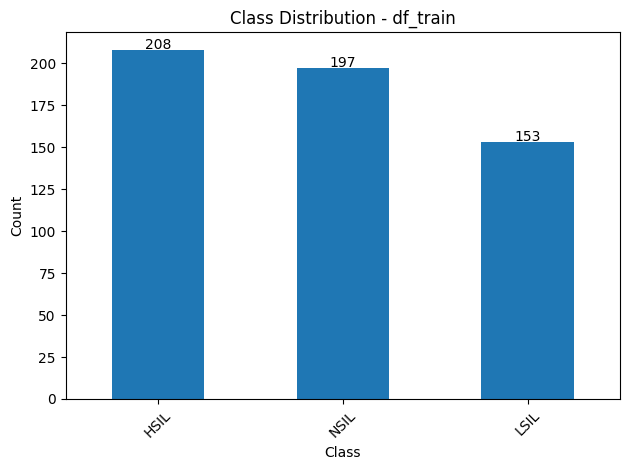

In [4]:
df1 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train.csv')
df2 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val.csv')
df_train = pd.concat([df1, df2], ignore_index=True)
df_train['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - df_train')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,6378,14898,0.428111,396.190905,594.274166,0.666680,61.273155,0.703130,149.482440,0.606072,...,0.950168,0.987997,0.961711,90.115048,137.726986,0.654302,-0.228032,-0.097290,2.343838,HSIL
1,6557,12602,0.520314,412.374670,492.801077,0.836797,62.680798,0.716702,153.808322,0.744296,...,0.943385,1.000556,0.942861,91.370847,126.670299,0.721328,5.439876,-4829.849982,-0.001126,HSIL
2,1353,3288,0.411496,175.396968,298.409161,0.587773,23.428492,0.654546,76.295478,0.613176,...,1.009701,0.991706,1.018146,41.505338,64.702485,0.641480,-0.342323,-0.492934,0.694461,HSIL
3,1357,2554,0.531323,180.066016,233.078207,0.772556,23.426064,0.697542,74.652528,0.759039,...,0.991959,0.999609,0.992347,41.566646,57.025028,0.728919,-3.104588,-9.747040,0.318516,HSIL
4,14851,41568,0.357270,604.256921,913.879285,0.661200,117.153717,0.648408,204.658252,0.626758,...,0.922652,0.979927,0.941552,137.509565,230.056561,0.597721,-2.107840,5.487555,-0.384113,HSIL


In [6]:
df_train.shape

(558, 26)

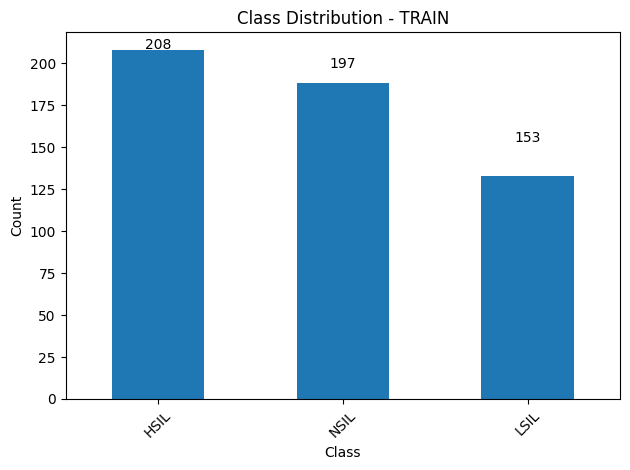

In [7]:
df = df_train[df_train['N'] != 0]
df['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TRAIN')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## TEST SET

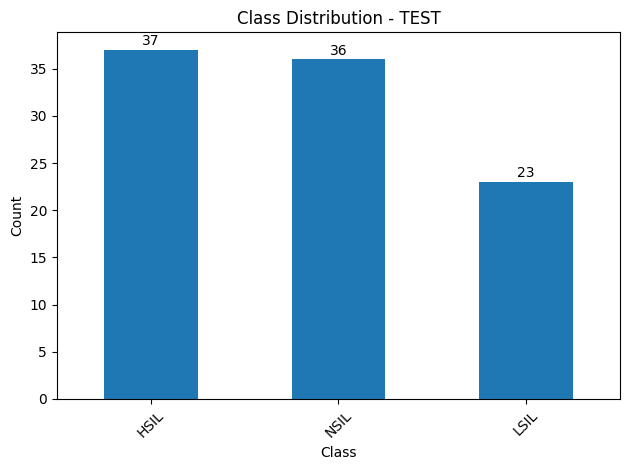

In [8]:
df_test = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test.csv')
df_test = df_test[df_test['N'] != 0]
df_test['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TEST')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_test['class'].value_counts()):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df_test.shape    

(96, 26)

## SMOTE FOR UNBALANCED DATA

In [314]:
import pandas as pd
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

X = df_train.drop('class', axis=1)  
y = df_train['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled_train, y_resampled_train = smote.fit_resample(X_scaled, y)

df_train = pd.DataFrame(X_resampled_train, columns=X.columns)
df_train['class'] = y_resampled_train

print(df_train['class'].value_counts())

joblib.dump(scaler, "scaler.pkl")


class
HSIL    208
LSIL    208
NSIL    208
Name: count, dtype: int64


['scaler.pkl']

## Analiza zbiorów danych

In [ ]:
import numpy as np


def analyze_data(df):
    TARGET = "class"
    NUM_COLS = [c for c in df.columns if c != TARGET]  # wszystkie cechy liczbowe

    # Rozmiar i podstawy
    print("Shape:", df.shape)
    print("\nPodgląd:")
    display(df.head())

    # Braki danych
    na_counts = df.isna().sum().sort_values(ascending=False)
    print("\nBraki danych:")
    display(na_counts[na_counts > 0])

    # Statystyki opisowe
    print("\nStatystyki opisowe:")
    display(df[NUM_COLS].describe().T)

    # Skośność rozkładów
    skew = df[NUM_COLS].skew().sort_values(ascending=False)
    print("\nSkośność cech (skew):")
    display(skew)

    # Korelacje (Pearson)
    corr = df[NUM_COLS].corr()
    print("\nTop pary o najwyższej korelacji:")
    abs_corr = corr.abs()
    upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .head(15)
    )
    display(pairs)

    # Rozkład klas
    print("\nRozkład klas:")
    display(df[TARGET].value_counts())

analyze_data(df_train)

Shape: (624, 26)

Podgląd:


,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,-0.010901,-1.176488,1.280386,0.387657,-0.602190,0.894778,-0.009354,1.414025,0.851088,0.957927,...,-0.269919,0.383809,-0.334354,0.338419,-0.831735,1.259212,-0.078687,0.058988,-0.008080,HSIL
1,0.011863,-1.331500,1.754310,0.450261,-0.984096,1.429918,0.017117,1.465799,0.911207,1.477768,...,-0.284002,0.440295,-0.368111,0.360662,-1.000983,1.531050,0.281913,-12.156916,-0.013565,HSIL
2,-0.649934,-1.960323,1.194986,-0.466439,-1.715713,0.646560,-0.721042,1.228691,-0.166036,0.984646,...,-0.146301,0.400491,-0.233288,-0.522536,-1.949538,1.207208,-0.085958,0.057988,-0.011938,HSIL
3,-0.649426,-2.009878,1.810897,-0.448378,-1.961593,1.227833,-0.721087,1.392710,-0.188869,1.533214,...,-0.183142,0.436035,-0.279490,-0.521450,-2.067058,1.561837,-0.261697,0.034581,-0.012817,HSIL
4,1.066618,0.624103,0.916262,1.192518,0.600681,0.877538,1.041508,1.205277,1.617900,1.035724,...,-0.327054,0.347514,-0.370456,1.177852,0.581574,1.029734,-0.198283,0.073114,-0.014460,HSIL



Braki danych:


Series([], dtype: int64)


Statystyki opisowe:


...

OrN      15.087353
NCOr     10.476377
Car       2.211744
NCExt     1.851079
NCs       1.660982
NSol      1.292490
N         1.215661
Nar       1.018351
NCr       0.972229
NExt      0.885836
Np        0.689088
MinA      0.685715
EqN       0.584434
MaxA      0.570837
NCp       0.565159
MinAr     0.474834
MaxAr     0.409865
NCEq      0.378448
NCar     -0.094831
C        -0.835662
Cp       -1.138924
EqC      -1.595774
CExt     -2.317465
CSol     -3.230747
OrC     -18.406647
dtype: float64


Top pary o najwyższej korelacji:


MinA   EqN      0.986159
MinAr  NCEq     0.983913
MaxA   EqN      0.980812
MaxAr  NCEq     0.979021
NSol   NCs      0.978830
NCr    NCEq     0.969108
N      EqN      0.967479
C      EqC      0.966511
NCp    MaxAr    0.965554
N      MinA     0.961373
Np     MaxA     0.961302
NCr    MinAr    0.959898
MinA   MaxA     0.957003
Np     NCp      0.954360
MinAr  MaxAr    0.954322
dtype: float64


Rozkład klas:


class
HSIL    208
LSIL    208
NSIL    208
Name: count, dtype: int64

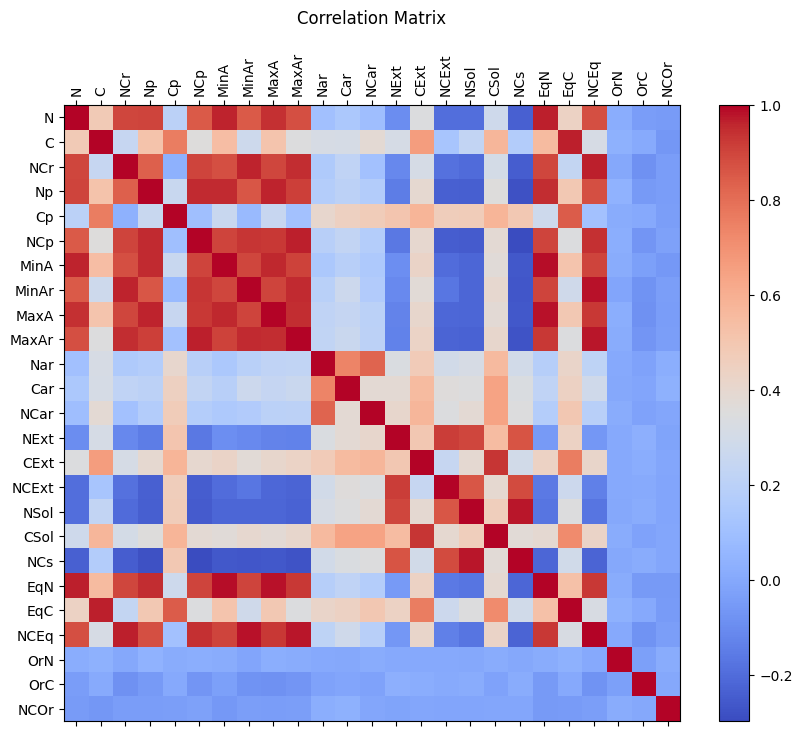

In [363]:
corr = df_train[['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
       'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
       'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

In [316]:

X_test = df_test.drop('class', axis=1)  
y_test = df_test['class']
X_scaled_test = scaler.transform(X_test)
df_test = pd.DataFrame(X_scaled_test, columns=X.columns)
df_test['class'] = y_test

print(df_test['class'].value_counts())


class
HSIL    37
NSIL    29
LSIL    23
Name: count, dtype: int64


## Uczenie modeli z kf foldem, ocena na teście i wybór najlepszego 

In [317]:
from sklearn.preprocessing import LabelEncoder
import joblib

le = LabelEncoder()

y_resampled_train = le.fit_transform(y_resampled_train)
y_test  = le.transform(y_test)

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "activation": ["relu", "tanh", "logistic"],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.001, 0.01, 0.1],
        "max_iter": [500, 1000]
    },
    "RandomForest": {
        "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "max_depth": [-1, 10, 20],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 50, 100],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

models = {
    "SVM": SVC(probability=True, random_state=42),
    "NeuralNet": MLPClassifier(solver="adam", random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", use_label_encoder=False, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = []

for name in models:
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_resampled_train, y_resampled_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    joblib.dump(best_model, f"best_model_{name}2.pkl")

    y_test_pred = best_model.predict(X_scaled_test)
    results.append({
        "Model": name,
        "Best_Params": best_params,
        "Dataset": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

df_results = pd.DataFrame(results)
print("\n=== Wyniki ===")
print(df_results)

df_results.to_csv("model_results2.csv", index=False)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:50:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5207
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [319]:
results = pd.read_csv("model_results2.csv")
results

,Model,Best_Params,Dataset,Accuracy,Precision,Recall,F1
0,SVM,"{'C': 10, 'gamma': 1, 'kernel': 'rbf'}",Test,0.729167,0.739130,0.708676,0.715084
1,NeuralNet,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",Test,0.781250,0.773579,0.782391,0.771983
2,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",Test,0.791667,0.775153,0.780683,0.776200
3,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",Test,0.822917,0.808413,0.813194,0.810185
4,LightGBM,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",Test,0.822917,0.808413,0.813194,0.810185


In [320]:

def predict(model, label_encoder, input_features, scaler):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    X_new_scaled = scaler.transform(X_new)

    y_pred_encoded = model.predict(X_new_scaled)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class


In [338]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\best_model_XGBoost2.pkl")
label_encoder = joblib.load("label_encoder.pkl")
scaler = joblib.load("scaler.pkl")

In [339]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\LSIL\1b_1_aug0.png')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(model=model_class, label_encoder=label_encoder, input_features=features, scaler=scaler)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(7086), 'C': np.uint64(37887), 'NCr': np.float64(0.18702985192810198), 'Np': 324.29141092300415, 'Cp': 858.7493418455124, 'NCp': 0.377632208982052, 'MinA': 80.95867156982422, 'MinAr': 0.4499491341181842, 'MaxA': np.float64(108.57716150277645), 'MaxAr': np.float64(0.38110154626713943), 'Nar': 0.9393939393939394, 'Car': 0.92578125, 'NCar': 1.0147040020457743, 'NExt': np.float64(0.7696318018898664), 'CExt': np.float64(0.6244560917721519), 'NCExt': np.float64(1.2324834556513309), 'NSol': np.float64(1.038698328935796), 'CSol': np.float64(0.9335797449639623), 'NCs': np.float64(1.1125973271580474), 'EqN': np.float64(94.98513259449273), 'EqC': np.float64(219.63430203722987), 'NCEq': np.float64(0.4324694809210264), 'OrN': np.float64(-7.186521930228615), 'OrC': np.float64(-10.375873882964356), 'NCOr': np.float64(0.6926184735174756)}
Predicted class: LSIL


In [340]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\NSIL\22c_1.bmp')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(model=model_class, label_encoder=label_encoder, input_features=features, scaler=scaler)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(451), 'C': np.uint64(28510), 'NCr': np.float64(0.015819010873377764), 'Np': 77.69848418235779, 'Cp': 818.2640600204468, 'NCp': 0.09495526930562764, 'MinA': 20.0, 'MinAr': 0.10188354593791907, 'MaxA': np.float64(26.92582403567252), 'MaxAr': np.float64(0.12398212734070096), 'Nar': 1.2380952380952381, 'Car': 0.9801980198019802, 'NCar': 1.263107263107263, 'NExt': np.float64(0.826007326007326), 'CExt': np.float64(0.7128212821282128), 'NCExt': np.float64(1.1587860052960017), 'NSol': np.float64(1.0636792452830188), 'CSol': np.float64(0.9230569990125136), 'NCs': np.float64(1.1523440550485429), 'EqN': np.float64(23.96311821686732), 'EqC': np.float64(190.52574477062015), 'NCEq': np.float64(0.125773649360181), 'OrN': np.float64(0.6174438538173612), 'OrC': np.float64(-1.9189982949348015), 'NCOr': np.float64(-0.32175320605917423)}
Predicted class: NSIL


In [341]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val\HSIL\2b_1.jpg')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(model=model_class, label_encoder=label_encoder, input_features=features, scaler=scaler)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}
Predicted class: HSIL


In [342]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
predicted_class = predict(model=model_class, label_encoder=label_encoder, input_features=features, scaler=scaler)
print("Predicted class:", predicted_class)

Predicted class: NSIL


In [343]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_multiclass_roc(y_true, y_proba, classes, title="ROC Curve"):
    """
    Rysuje wykres ROC dla problemu wieloklasowego (One-vs-Rest).
    
    y_true : array-like (n_samples,)
        Prawdziwe etykiety zakodowane liczbowo.
    y_proba : array-like (n_samples, n_classes)
        Prawdopodobieństwa przewidziane przez model.
    classes : list
        Lista nazw klas.
    """
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    # AUC ROC score macro
    macro_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC: {macro_auc:.4f}")

    # Rysowanie krzywych ROC
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    """
    Rysuje macierz pomyłek z etykietami klas.
    """
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


## NN

In [344]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\best_model_NeuralNet2.pkl")

In [345]:
y_test_pred = model_class.predict(X_scaled_test)
label_encoder = joblib.load("label_encoder.pkl")
classes = list(label_encoder.classes_)

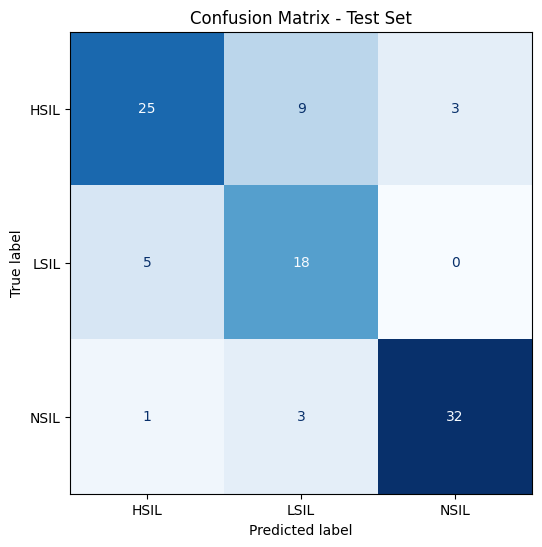

In [346]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC: 0.9307


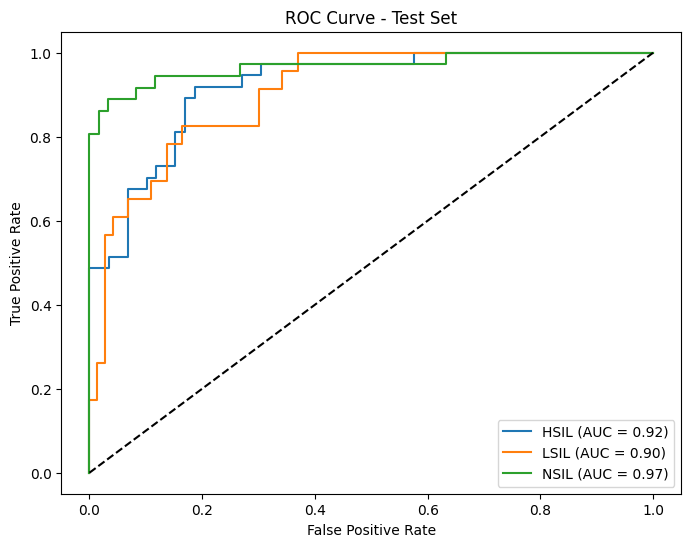

In [347]:
plot_multiclass_roc(y_test, model_class.predict_proba(X_scaled_test), classes, title="ROC Curve - Test Set")

## XGBOOST

In [348]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\best_model_XGBoost2.pkl")
label_encoder = joblib.load("label_encoder.pkl")

In [349]:
y_test_pred = model_class.predict(X_scaled_test)
label_encoder = joblib.load("label_encoder.pkl")
classes = list(label_encoder.classes_)

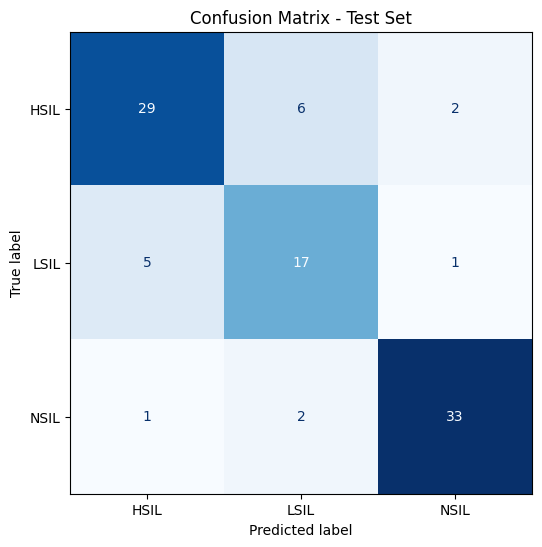

In [350]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC: 0.9404


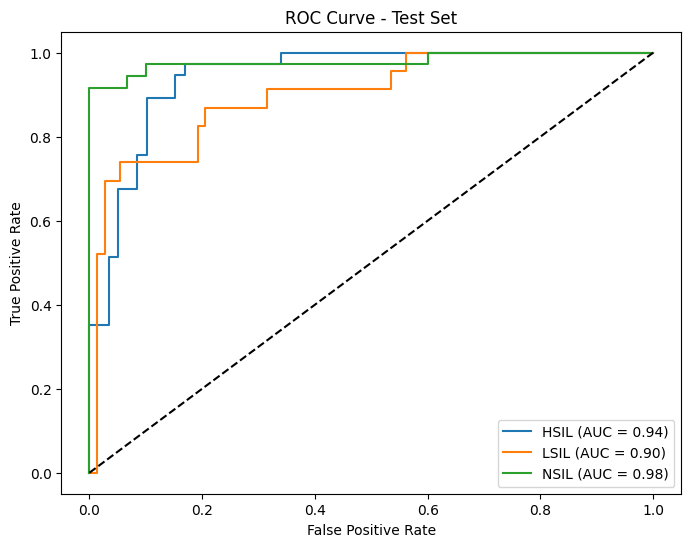

In [351]:
plot_multiclass_roc(y_test, model_class.predict_proba(X_scaled_test), classes, title="ROC Curve - Test Set")

In [358]:
accuracy_score = accuracy_score(y_test, y_test_pred)
precision_score = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
recall_score = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
f1_score = f1_score(y_test, y_test_pred, average="macro", zero_division=0)  
print(f"Accuracy: {accuracy_score:.4f}")
print(f"Precision: {precision_score:.4f}")  
print(f"Recall: {recall_score:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.8229
Precision: 0.8084
Recall: 0.8132
F1 Score: 0.8102


## LIGHT GBM

In [369]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\best_model_LightGBM2.pkl")
label_encoder = joblib.load("label_encoder.pkl")

In [370]:
y_test_pred = model_class.predict(X_scaled_test)
label_encoder = joblib.load("label_encoder.pkl")
classes = list(label_encoder.classes_)

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


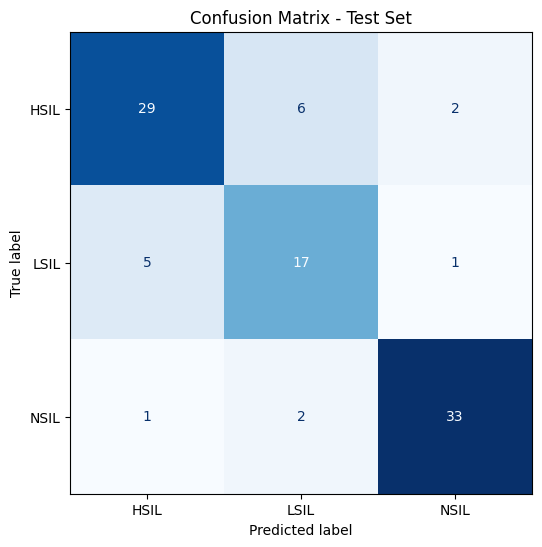

In [371]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC: 0.9286


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


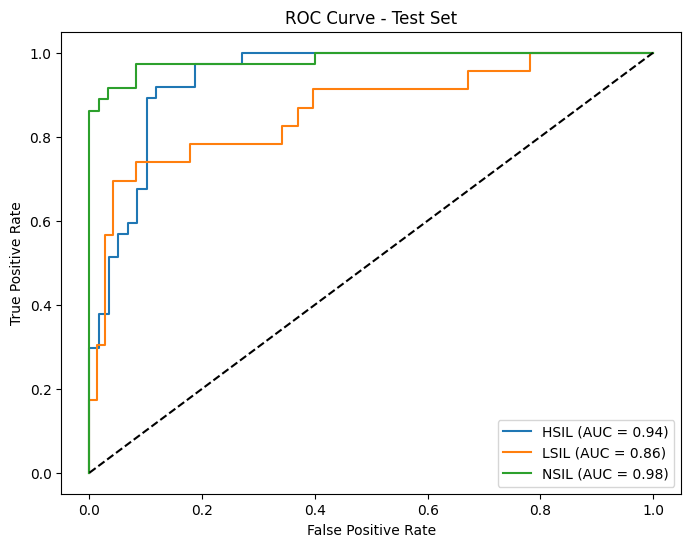

In [372]:
plot_multiclass_roc(y_test, model_class.predict_proba(X_scaled_test), classes, title="ROC Curve - Test Set")

## SHAP

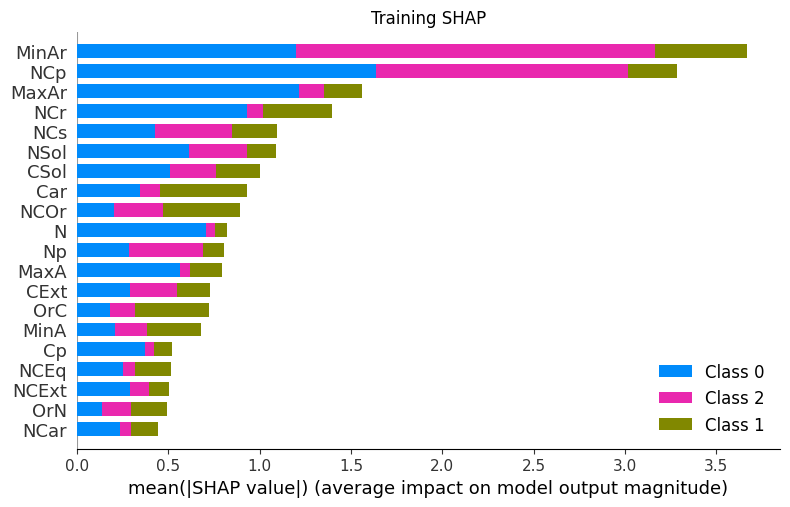

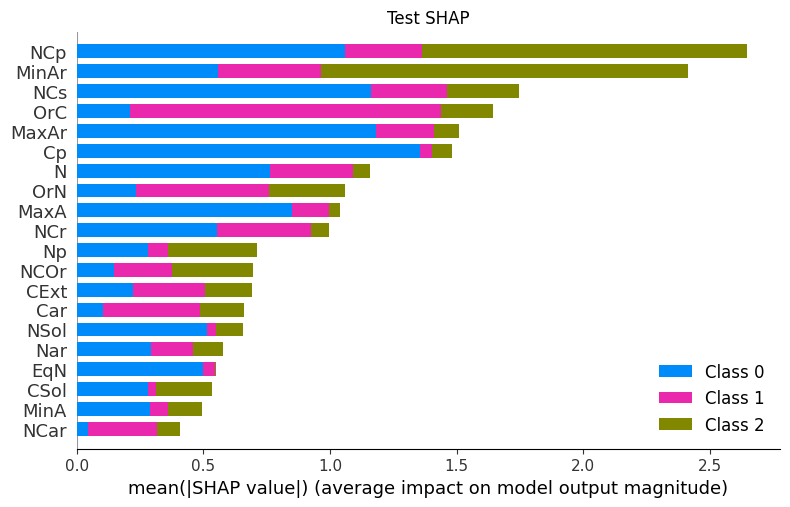

In [ ]:
import shap


train_shap_values = shap.TreeExplainer(model_class).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('Training SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

## LIME

In [ ]:
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model = joblib.load("best_model_XGBoost2.pkl")        
scaler = joblib.load("scaler.pkl")                    
label_encoder = joblib.load("label_encoder.pkl")      

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])  # numeryczne etykiety

df_test = df_test[df_test[TARGET].notna()]  # usuń wiersze z brakującymi etykietami
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=label_encoder.classes_,   
    mode="classification"
)

sample_idx = 0  
sample = X_test_scaled[sample_idx]

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict_proba, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation.html")


In [410]:
features = {'N': np.uint64(14601), 'C': np.uint64(29238), 'NCr': np.float64(0.49938436281551407), 'Np': 953.5117527246475, 'Cp': 691.3137083053589, 'NCp': 1.3792750545364183, 'MinA': 145.0, 'MinAr': 0.9602649006622517, 'MaxA': np.float64(198.17668884104407), 'MaxAr': np.float64(0.806122640258427), 'Nar': 1.2054794520547945, 'Car': 1.2828947368421053, 'NCar': 0.9396557780119423, 'NExt': np.float64(0.5682207347447074), 'CExt': np.float64(0.9864372469635627), 'NCExt': np.float64(0.5760333325751805), 'NSol': np.float64(0.7645703513640886), 'CSol': np.float64(0.9984291763420298), 'NCs': np.float64(0.7657732460956963), 'EqN': np.float64(136.34724270288018), 'EqC': np.float64(192.94293925657576), 'NCEq': np.float64(0.7066713258761206), 'OrN': np.float64(0.41287032207930696), 'OrC': np.float64(-0.004661230487324492), 'NCOr': np.float64(-88.57539295729852)}
row = features.values()
row = np.array(list(row))

In [411]:
row

array([ 1.46010000e+04,  2.92380000e+04,  4.99384363e-01,  9.53511753e+02,
        6.91313708e+02,  1.37927505e+00,  1.45000000e+02,  9.60264901e-01,
        1.98176689e+02,  8.06122640e-01,  1.20547945e+00,  1.28289474e+00,
        9.39655778e-01,  5.68220735e-01,  9.86437247e-01,  5.76033333e-01,
        7.64570351e-01,  9.98429176e-01,  7.65773246e-01,  1.36347243e+02,
        1.92942939e+02,  7.06671326e-01,  4.12870322e-01, -4.66123049e-03,
       -8.85753930e+01])

In [412]:
exp = explainer.explain_instance(
    data_row=row,
    predict_fn=model.predict_proba, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation.html")

## Uczenie z ograniczonymi cechami - bez skorelowanych 

In [436]:
corr_matrix = df_train.drop(columns='class').corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df_train_uncorr = df_train.drop(columns=to_drop)

print("Kolumny usunięte:", to_drop)
df_train_uncorr.head()

Kolumny usunięte: ['Np', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'NCExt', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq']


,N,C,NCr,Cp,Nar,Car,NCar,NExt,CExt,NSol,OrN,OrC,NCOr,class
0,-0.010901,-1.176488,1.280386,-0.602190,-1.362387,-1.743446,0.552538,-0.211444,0.132836,-0.269919,-0.078687,0.058988,-0.008080,HSIL
1,0.011863,-1.331500,1.754310,-0.984096,0.290606,0.213168,0.245432,-0.689346,-0.566908,-0.284002,0.281913,-12.156916,-0.013565,HSIL
2,-0.649934,-1.960323,1.194986,-1.715713,4.574441,5.329728,0.126544,-0.157078,-0.179401,-0.146301,-0.085958,0.057988,-0.011938,HSIL
3,-0.649426,-2.009878,1.810897,-1.961593,0.415986,-0.000250,0.627394,-0.982875,-0.994398,-0.183142,-0.261697,0.034581,-0.012817,HSIL
4,1.066618,0.624103,0.916262,0.600681,0.783621,0.009218,1.058740,-0.435740,0.033019,-0.327054,-0.198283,0.073114,-0.014460,HSIL


In [437]:
df_train_uncorr.shape

(624, 14)

In [438]:
df_train_uncorr.columns

Index(['N', 'C', 'NCr', 'Cp', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NSol',
       'OrN', 'OrC', 'NCOr', 'class'],
      dtype='object')

In [439]:
X = df_train_uncorr.drop('class', axis=1)  
y = df_train_uncorr['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled_train, y_resampled_train = smote.fit_resample(X_scaled, y)

df_train_uncorr = pd.DataFrame(X_resampled_train, columns=X.columns)
df_train_uncorr['class'] = y_resampled_train

print(df_train_uncorr['class'].value_counts())

joblib.dump(scaler, "scaler_uncor.pkl")


class
HSIL    208
LSIL    208
NSIL    208
Name: count, dtype: int64


['scaler_uncor.pkl']

In [440]:
df_test_uncorr = df_test.drop(columns=to_drop)
X_test = df_test_uncorr.drop('class', axis=1)  
y_test = df_test_uncorr['class']
X_scaled_test = scaler.transform(X_test)
df_test_uncorr = pd.DataFrame(X_scaled_test, columns=X.columns)
df_test_uncorr['class'] = y_test

print(df_test_uncorr['class'].value_counts())

class
HSIL    37
LSIL    23
NSIL    22
Name: count, dtype: int64


In [441]:

y_resampled_train = le.fit_transform(y_resampled_train)
y_test  = le.transform(y_test)


In [442]:
from sklearn.metrics import (
    accuracy_score as sk_acc,
    precision_score as sk_prec,
    recall_score as sk_rec,
    f1_score as sk_f1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "activation": ["relu", "tanh", "logistic"],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.001, 0.01, 0.1],
        "max_iter": [500, 1000]
    },
    "RandomForest": {
        "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "max_depth": [-1, 10, 20],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 50, 100],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

models = {
    "SVM": SVC(probability=True, random_state=42),
    "NeuralNet": MLPClassifier(solver="adam", random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", use_label_encoder=False, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = []

for name in models:
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_resampled_train, y_resampled_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    # Zapis modelu
    joblib.dump(best_model, f"best_model_{name}_uncorr.pkl")

    # Ocena na teście
    y_test_pred = best_model.predict(X_scaled_test)
    results.append({
        "Model": name,
        "Best_Params": best_params,
        "Dataset": "Test",
        "Accuracy": sk_acc(y_test, y_test_pred),
        "Precision": sk_prec(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": sk_rec(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": sk_f1(y_test, y_test_pred, average="macro", zero_division=0)
    })

# ===== 8. DataFrame z wynikami =====
df_results = pd.DataFrame(results)
print("\n=== Wyniki ===")
print(df_results)

# Zapis wyników do CSV
df_results.to_csv("model_results_uncorr.csv", index=False)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2710
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [443]:
results = pd.read_csv("model_results_uncorr.csv")
results

,Model,Best_Params,Dataset,Accuracy,Precision,Recall,F1
0,SVM,"{'C': 1, 'gamma': 1, 'kernel': 'rbf'}",Test,0.685393,0.658730,0.661548,0.657812
1,NeuralNet,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",Test,0.662921,0.642049,0.650985,0.639235
2,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",Test,0.707865,0.676206,0.679052,0.671167
3,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.2...",Test,0.741573,0.716027,0.714048,0.707071
4,LightGBM,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",Test,0.730337,0.697770,0.700069,0.695803
